# Data Pre-Processing

#### Import Packages and CSV

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
# machine learning models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
#from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression

# preprocessing functions and evaluation models
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,roc_auc_score
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import StandardScaler
#from catboost import CatBoostClassifier

%matplotlib inline
# Supress unnecessary warnings
import warnings
warnings.filterwarnings('ignore')

**Import the CSV Data as Pandas DataFrame**

In [2]:
# Column names for Covertype dataset
col_names = [
    "Elevation", "Aspect", "Slope", "Horizontal_Distance_To_Hydrology",
    "Vertical_Distance_To_Hydrology", "Horizontal_Distance_To_Roadways",
    "Hillshade_9am", "Hillshade_Noon", "Hillshade_3pm",
    "Horizontal_Distance_To_Fire_Points"
] + [f"Wilderness_Area_{i}" for i in range(4)] \
  + [f"Soil_Type_{i}" for i in range(40)] \
  + ["Cover_Type"]

# Read the gzip-compressed CSV file
df = pd.read_csv("covtype.data.gz", compression="gzip", header=None, names=col_names)

# Check it
df.head()


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type_31,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,5


## Data Cleaning
#### Checking features with nan value

In [ ]:
features_with_na=[features for features in df.columns if df[features].isnull().sum()>=1]
for feature in features_with_na:
    print(feature,np.round(df[feature].isnull().mean()*100,5), '% missing values')

**Handling Duplicates**

In [ ]:
df.duplicated().sum()

np.int64(0)

# Feature Engineering
### Type of Features
**Numeric Features**

In [ ]:
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
print('Number of Numerical Features :', len(numeric_features))

Number of Numerical Features : 55


**Categorical Features**

In [ ]:
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']
print('Number of Categorical Features :', len(categorical_features))

Number of Categorical Features : 0


**Discrete Features**

In [ ]:
discrete_features=[feature for feature in numeric_features if (len(df[feature].unique())<=25)]
print('Number of Discrete Features :',len(discrete_features))

Number of Discrete Features : 45


**Continuous features**

In [ ]:
continuous_features=[feature for feature in numeric_features if len(df[feature].unique()) > 25]
print('Number of Continuous Features :',len(continuous_features))

Number of Continuous Features : 10


### Check Outlier and Capping it
**Why outliers?**
* Data Entry error : Human error.
* Measurement error: Instrument error.
* Natural error: it will be Real life data.
* Intentional error: People give wrong inputs

**Impact of Outliers ?**
* Ouliers can very high impact on few Machine learning models.
* Can Cause bias in the output.

**Checking Outliers in Continuous features**

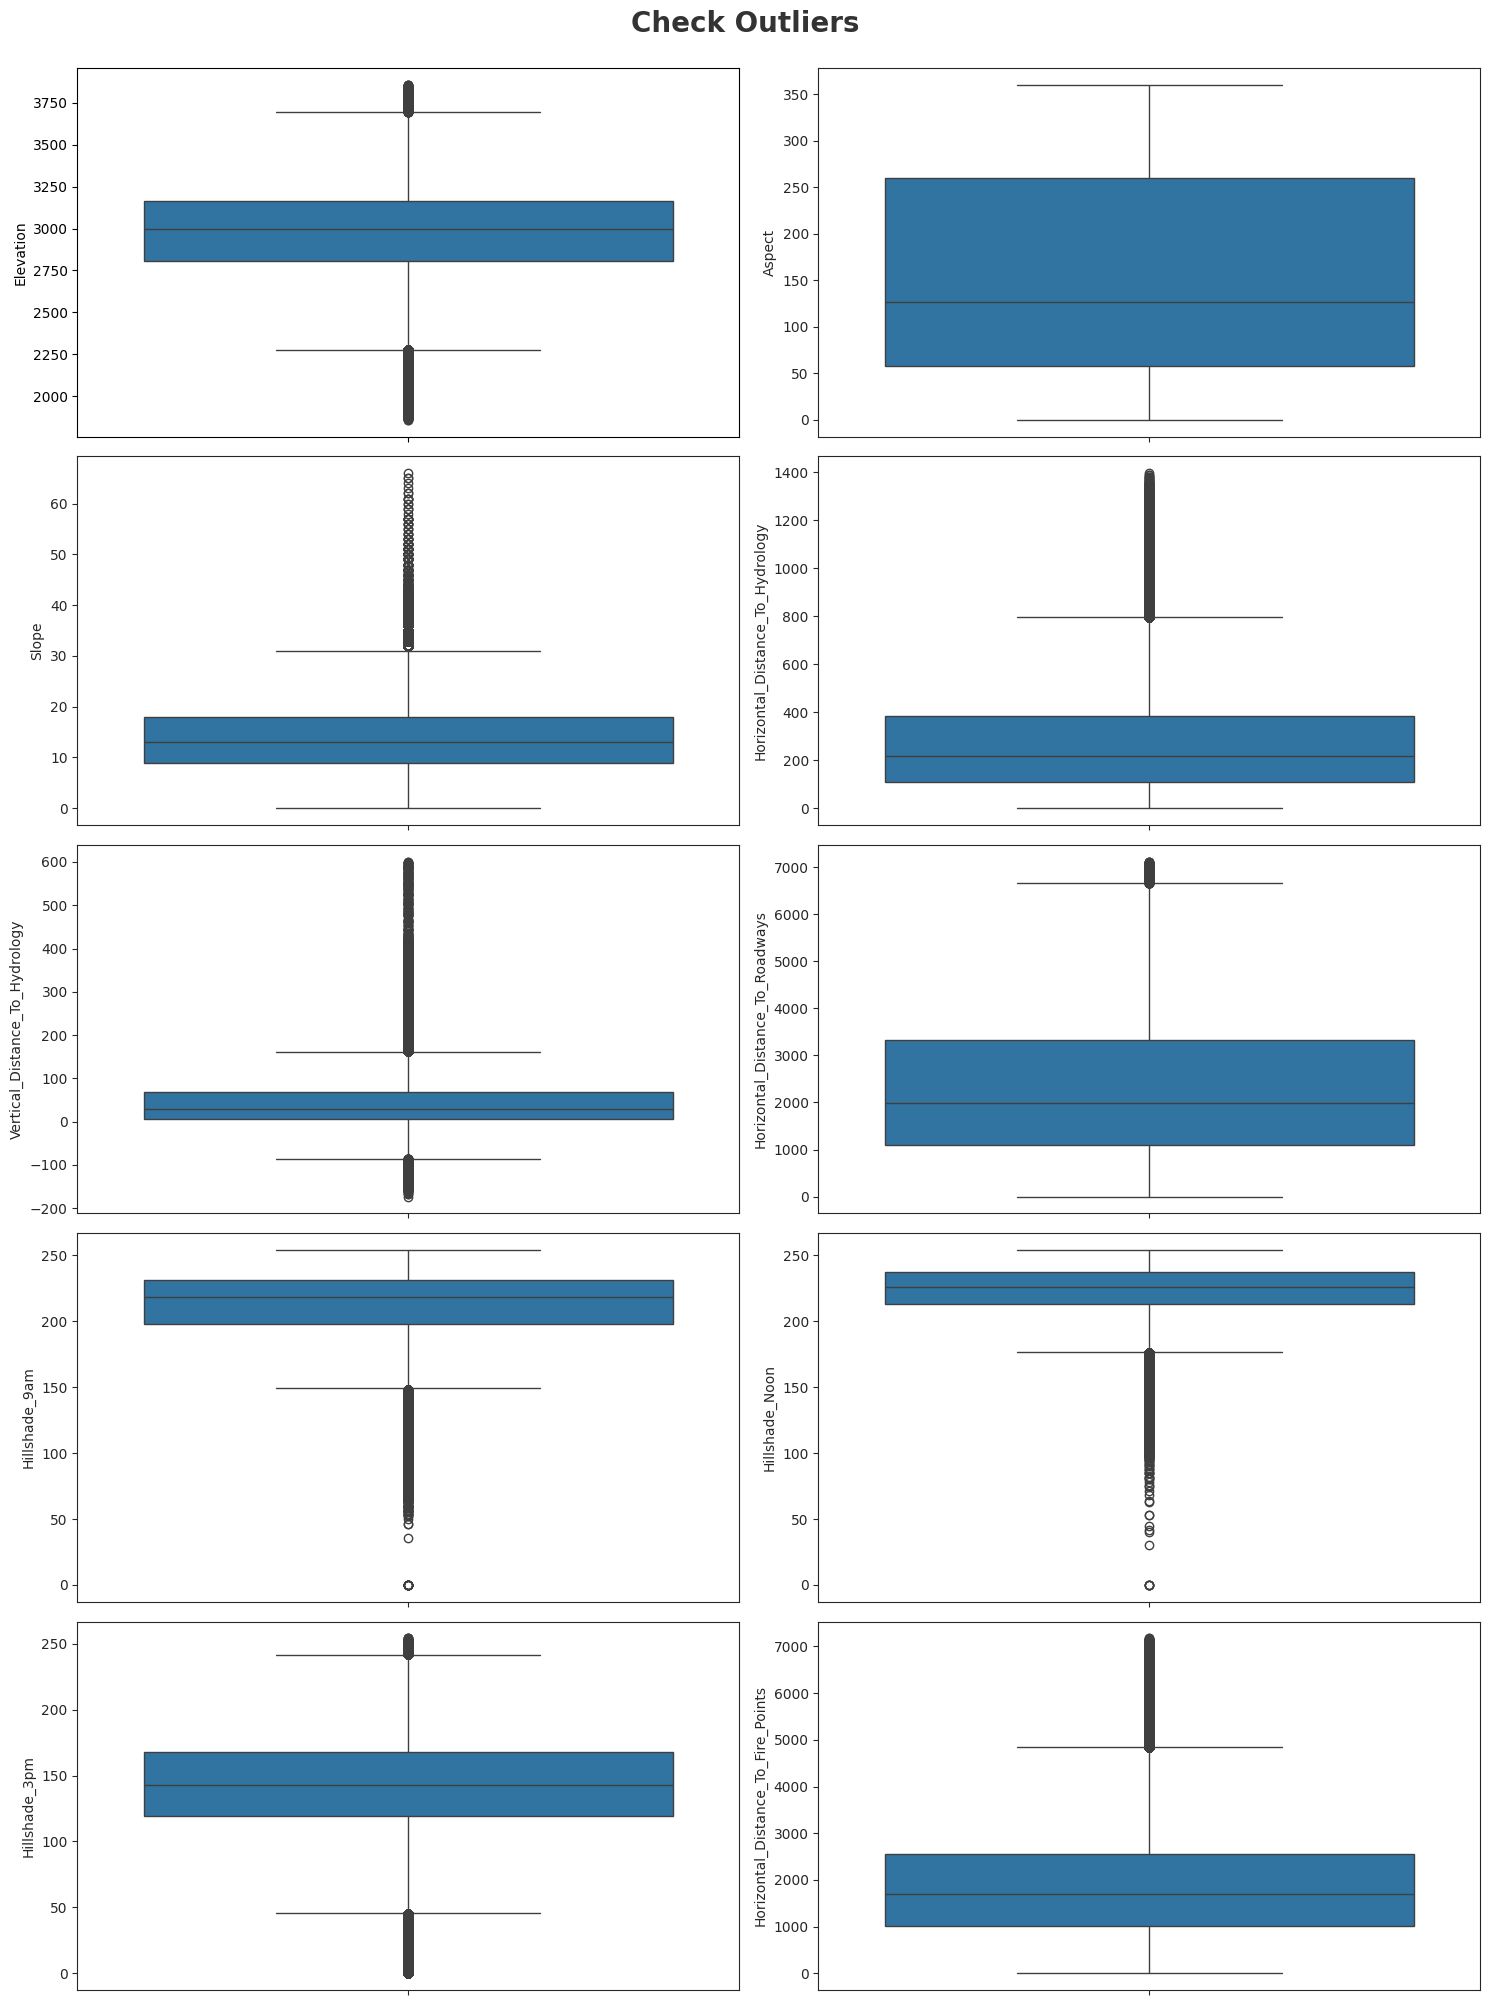

In [ ]:
plt.figure(figsize=(15, 20))
plt.suptitle('Check Outliers', fontsize=20, fontweight='bold', alpha=0.8, y=1.)
for i in range(0, len(continuous_features)):
    plt.subplot(5, 2, i+1)
    sns.set_style('ticks')
    sns.boxplot(df[continuous_features[i]])
    plt.tight_layout()

#### Insight
- Except 'Aspect' rest all other 9 continuous features has outliers.

In [ ]:
#The goal of this function is to detect outliers in a column and then cap (limit) them so they don't exceed a defined range.
#This helps reduce the influence of extreme values (outliers) that can skew statistical models or visualizations.

df_copy = df.copy()
def detect_and_capping_outliers(col):
    # Finding the IQR
    percentile25 = df_copy[col].quantile(0.25)
    percentile75 = df_copy[col].quantile(0.75)
    iqr = percentile75 - percentile25
#IQR is the range between the 25th percentile and the 75th percentile.
#It represents the middle 50% of the data and is a common way to detect outliers.
#Determine Outlier Boundaries
    upper_limit = percentile75 + 1.5 * iqr
    lower_limit = percentile25 - 1.5 * iqr
#Cap the Outliers
    df_copy.loc[(df[col]>upper_limit), col]= upper_limit
    df_copy.loc[(df[col]<lower_limit), col]= lower_limit
    return df_copy

In [ ]:
for col in continuous_features:
         detect_and_capping_outliers(col)

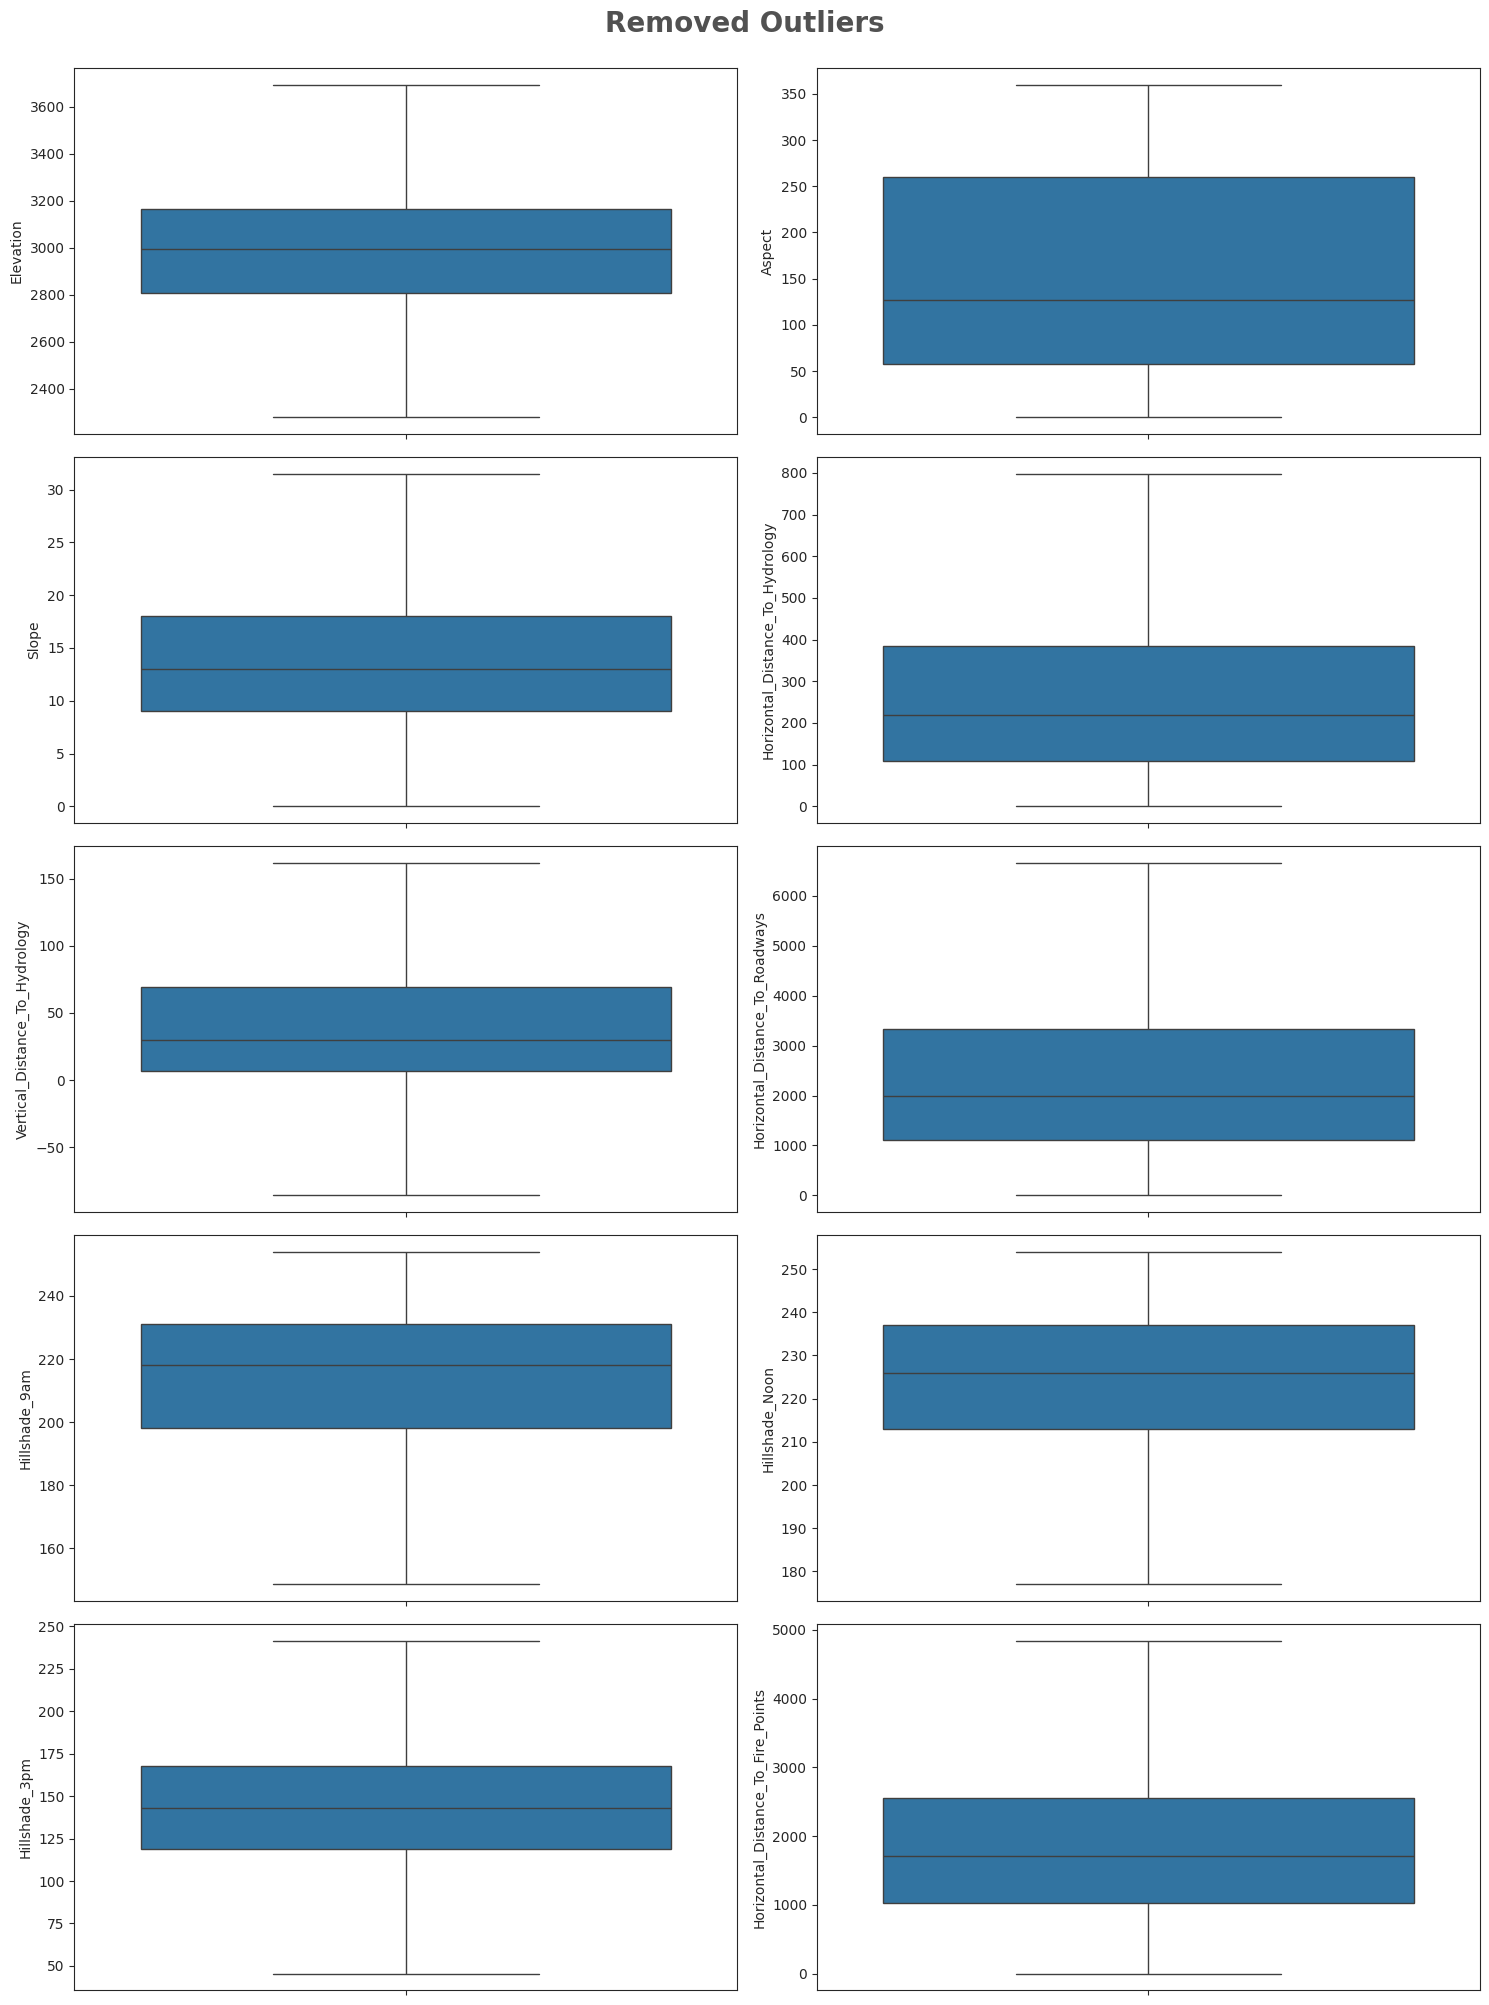

In [ ]:
plt.figure(figsize=(15, 20))
plt.suptitle('Removed Outliers', fontsize=20, fontweight='bold', alpha=0.8, y=1.)
for i in range(0, len(continuous_features)):
    plt.subplot(5, 2, i+1)
    sns.set_style('ticks')
    sns.boxplot(df_copy[continuous_features[i]])
    plt.tight_layout()

In [ ]:
df.columns

Index(['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Wilderness_Area_0',
       'Wilderness_Area_1', 'Wilderness_Area_2', 'Wilderness_Area_3',
       'Soil_Type_0', 'Soil_Type_1', 'Soil_Type_2', 'Soil_Type_3',
       'Soil_Type_4', 'Soil_Type_5', 'Soil_Type_6', 'Soil_Type_7',
       'Soil_Type_8', 'Soil_Type_9', 'Soil_Type_10', 'Soil_Type_11',
       'Soil_Type_12', 'Soil_Type_13', 'Soil_Type_14', 'Soil_Type_15',
       'Soil_Type_16', 'Soil_Type_17', 'Soil_Type_18', 'Soil_Type_19',
       'Soil_Type_20', 'Soil_Type_21', 'Soil_Type_22', 'Soil_Type_23',
       'Soil_Type_24', 'Soil_Type_25', 'Soil_Type_26', 'Soil_Type_27',
       'Soil_Type_28', 'Soil_Type_29', 'Soil_Type_30', 'Soil_Type_31',
       'Soil_Type_32', 'Soil_Type_33', 'Soil_Type_34', 'Soil_Type_35',
       'Soil_Type_36', 'S

#### Create one column as Wilderness_Area_Type and represent it as categorical data

In [ ]:
df['Wilderness_Area_Type'] = (df.iloc[:, 10:15] == 1).idxmax(1)
#list of wilderness areas
wilderness_areas = sorted(df['Wilderness_Area_Type'].value_counts().index.tolist())

In [ ]:
wilderness_areas

['Wilderness_Area_0',
 'Wilderness_Area_1',
 'Wilderness_Area_2',
 'Wilderness_Area_3']

In [ ]:
def split_numbers_chars(row):
    '''This function fetches the numerical characters at the end of a string
    and returns alphabetical character and numerical charcters respectively'''
    head = row.rstrip('0123456789')
    tail = row[len(head):]
    return head, tail

def reverse_one_hot_encode(dataframe, start_loc, end_loc, numeric_column_name):
    ''' this function takes the start and end location of the one-hot-encoded column set and numeric column name to be created as arguments
    1) transforms one-hot-encoded columns into one column consisting of column names with string data type
    2) splits string column into the alphabetical and numerical characters
    3) fetches numerical character and creates numeric column in the given dataframe
    '''
    dataframe['String_Column'] = (dataframe.iloc[:, start_loc:end_loc] == 1).idxmax(1)
    dataframe['Tuple_Column'] = dataframe['String_Column'].apply(split_numbers_chars)
    dataframe[numeric_column_name] = dataframe['Tuple_Column'].apply(lambda x: x[1]).astype('int64')
    dataframe.drop(columns=['String_Column','Tuple_Column'], inplace=True)

In [ ]:
df_copy = df.copy()
reverse_one_hot_encode(df_copy, 14, 56, "Soil_Type")

In [ ]:
feature_names = continuous_features + wilderness_areas + ["Soil_Type"] + ["Cover_Type"]
all_features_df = df_copy[feature_names]
all_features_df

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area_0,Wilderness_Area_1,Wilderness_Area_2,Wilderness_Area_3,Soil_Type,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,1,0,0,0,28,5
1,2590,56,2,212,-6,390,220,235,151,6225,1,0,0,0,28,5
2,2804,139,9,268,65,3180,234,238,135,6121,1,0,0,0,11,2
3,2785,155,18,242,118,3090,238,238,122,6211,1,0,0,0,29,2
4,2595,45,2,153,-1,391,220,234,150,6172,1,0,0,0,28,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
581007,2396,153,20,85,17,108,240,237,118,837,0,0,1,0,1,3
581008,2391,152,19,67,12,95,240,237,119,845,0,0,1,0,1,3
581009,2386,159,17,60,7,90,236,241,130,854,0,0,1,0,1,3
581010,2384,170,15,60,5,90,230,245,143,864,0,0,1,0,1,3


## Handling Imbalanced Target Variable(Cover_Type)

In [ ]:
all_features_df["Cover_Type"] = all_features_df["Cover_Type"]-1

In [ ]:
all_features_df["Cover_Type"].value_counts()

,count
Cover_Type,
1,283301
0,211840
2,35754
6,20510
5,17367
4,9493
3,2747


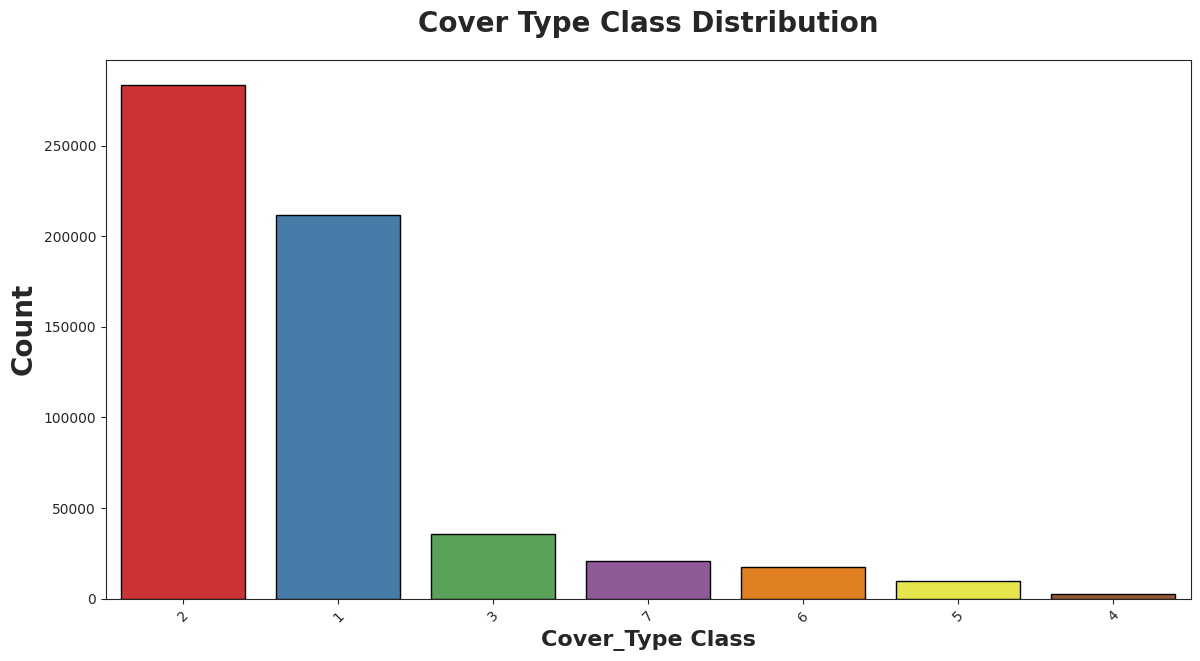

In [ ]:
plt.subplots(figsize=(14,7))
sns.countplot(x="Cover_Type", data=df,ec = "black",palette="Set1",order = df['Cover_Type'].value_counts().index)
plt.title("Cover Type Class Distribution", weight="bold",fontsize=20, pad=20)
plt.ylabel("Count", weight="bold", fontsize=20)
plt.xlabel("Cover_Type Class", weight="bold", fontsize=16)
plt.xticks(rotation= 45)

plt.show()

#### Inference
- As most of the data is of class 0 and class 1 type.
- So its a clear case of imbalaced data

In [ ]:
def split_and_scale_data(df):
    # Separate features and target
    X = df.drop("Cover_Type", axis=1)
    y = df["Cover_Type"]

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Standardize features
    scaler = StandardScaler()
    X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
    X_test = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

    return X_train, X_test, y_train, y_test

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

def evaluate_model(model, label, X_test, y_test):
    """
    Evaluate a trained classification model on test data.

    Parameters:
    - model: trained sklearn model
    - label: a string to label the output (e.g., model name)
    - X_test: features of test data
    - y_test: true labels of test data

    Returns:
    - accuracy as a float
    """

    print(f"\n🔍 Evaluating Model: {label}")

    # Make predictions
    y_pred = model.predict(X_test)

    # Compute accuracy
    accuracy = model.score(X_test, y_test) * 100
    print(f"✅ Accuracy: {accuracy:.2f}%")

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    print("\n📊 Confusion Matrix:\n", cm)

    # Plot confusion matrix
    plt.figure(figsize=(6, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {label}")
    plt.tight_layout()
    plt.show()

    # Classification report
    print("\n📋 Classification Report:\n")
    print(classification_report(y_test, y_pred))

    return accuracy

In [ ]:
imbalanced_data = all_features_df.copy()
X_train, X_test, y_train, y_test = split_and_scale_data(imbalanced_data)

model_1 = RandomForestClassifier()
model_1.fit(X_train, y_train)

RandomForestClassifier()


🔍 Evaluating Model: Imbalanced
✅ Accuracy: 95.88%

📊 Confusion Matrix:
 [[40442  2027     0     0     8     2    78]
 [ 1186 55064    97     1    79    57    16]
 [    2    86  6901    20     5   107     0]
 [    0     0    70   441     0    15     0]
 [   29   371    21     0  1565     9     0]
 [    2    94   206    17     4  3166     0]
 [  155    21     0     0     0     0  3839]]


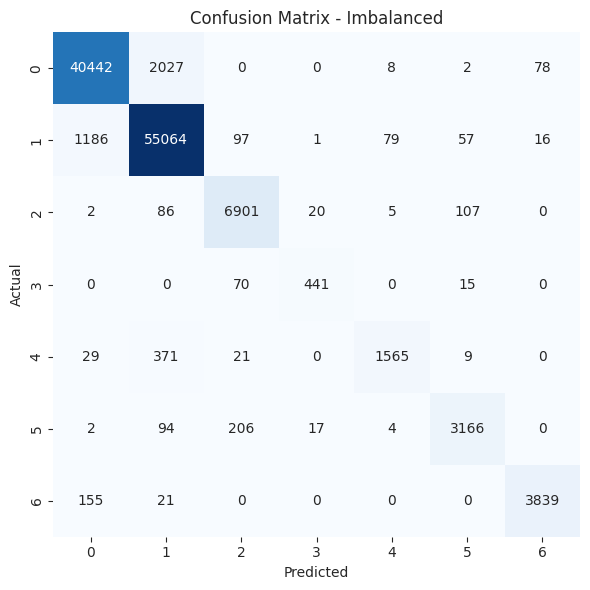


📋 Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.95      0.96     42557
           1       0.95      0.97      0.96     56500
           2       0.95      0.97      0.96      7121
           3       0.92      0.84      0.88       526
           4       0.94      0.78      0.86      1995
           5       0.94      0.91      0.93      3489
           6       0.98      0.96      0.97      4015

    accuracy                           0.96    116203
   macro avg       0.95      0.91      0.93    116203
weighted avg       0.96      0.96      0.96    116203



95.8822061392563

In [ ]:
evaluate_model(model_1,"Imbalanced",X_test, y_test)


🔍 Evaluating Model: Imbalanced
✅ Accuracy: 71.52%

📊 Confusion Matrix:
 [[29876 11880     5     0     0    17   779]
 [10850 44653   723     1     0   263    10]
 [    0   883  5665    73     0   500     0]
 [    0     2   305   155     0    64     0]
 [    4  1924    62     0     0     5     0]
 [    0   908  1828    36     0   717     0]
 [ 1899    69     0     0     0     0  2047]]


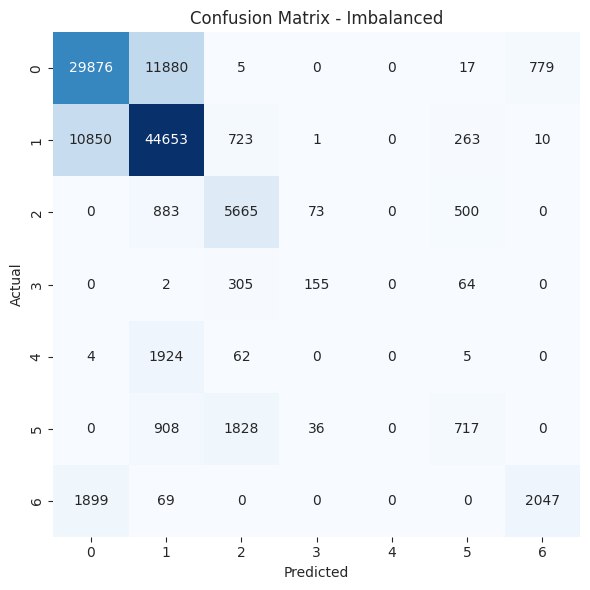


📋 Classification Report:

              precision    recall  f1-score   support

           0       0.70      0.70      0.70     42557
           1       0.74      0.79      0.76     56500
           2       0.66      0.80      0.72      7121
           3       0.58      0.29      0.39       526
           4       0.00      0.00      0.00      1995
           5       0.46      0.21      0.28      3489
           6       0.72      0.51      0.60      4015

    accuracy                           0.72    116203
   macro avg       0.55      0.47      0.49    116203
weighted avg       0.70      0.72      0.70    116203



71.5239709818163

In [37]:
model_2 = LogisticRegression()
model_2.fit(X_train, y_train)
evaluate_model(model_2,"Imbalanced",X_test, y_test)

In [38]:
y_pred_probabilities = model_2.predict_proba(X_test)

In [39]:
y_pred_probabilities

array([[5.30869802e-01, 4.38657869e-01, 3.54958127e-10, ...,
        5.39834739e-04, 4.86083180e-10, 2.99324933e-02],
       [4.23529553e-02, 8.64909541e-01, 3.08747187e-03, ...,
        6.63994478e-02, 2.32142438e-02, 9.95328461e-06],
       [1.29474432e-02, 4.94033488e-01, 1.53931885e-01, ...,
        3.39248438e-02, 3.05038668e-01, 1.69561160e-08],
       ...,
       [1.27506756e-01, 8.59080672e-01, 3.43803109e-07, ...,
        1.33267133e-02, 1.37250882e-06, 4.88754591e-05],
       [1.24560243e-01, 8.72098953e-01, 5.12400148e-07, ...,
        3.12389784e-03, 7.98469500e-07, 7.59620269e-05],
       [2.30086539e-01, 7.35957312e-02, 1.01997059e-08, ...,
        1.23196802e-04, 2.44756186e-07, 6.96194276e-01]])

#### Inference
- From above confusion matrix we can observe that most of the true positives and true negatives are from class 1 and Class 2 only.
- We have huge disconnection between over represented classes and under represented classes.

### 1. Random under-sampling
####  It consists of removing samples from the majority class (under-sampling)

In [40]:
under_sampled_data = all_features_df.copy()
under_sampled_data['Cover_Type'].value_counts()

,count
Cover_Type,
1,283301
0,211840
2,35754
6,20510
5,17367
4,9493
3,2747


In [41]:
minimum_class_size = np.min(under_sampled_data['Cover_Type'].value_counts().values)
print("Size of smallest class:",minimum_class_size)

Size of smallest class: 2747


In [42]:
class_subsets = [under_sampled_data.query("Cover_Type == " + str(i)) for i in range(7)]
class_subsets[0]

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area_0,Wilderness_Area_1,Wilderness_Area_2,Wilderness_Area_3,Soil_Type,Cover_Type
40,2699,347,3,0,0,2096,213,234,159,6853,1,0,0,0,19,0
51,2739,323,25,85,43,3118,149,205,192,6219,1,0,0,0,28,0
52,2696,72,2,30,0,3271,222,234,149,6071,1,0,0,0,29,0
55,2722,315,24,30,19,3216,148,212,200,6132,1,0,0,0,15,0
67,2919,13,13,90,6,5321,207,214,142,4060,1,0,0,0,28,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
565432,2826,72,14,67,13,2984,235,213,106,2082,0,0,1,0,23,0
565433,2820,69,14,42,7,2954,234,211,106,2065,0,0,1,0,23,0
565434,2812,67,16,30,0,2925,234,206,99,2047,0,0,1,0,23,0
565527,2832,45,17,85,19,2989,222,200,106,2058,0,0,1,0,23,0


#### Undersample the majority class
- We will go through the each class subsets and sample 2747 records.

In [43]:
class_subsets = [under_sampled_data.query("Cover_Type=="+str(i)) for i in range(7)]
for i in range(7):
    class_subsets[i] = class_subsets[i].sample(minimum_class_size)
under_sampled_data = pd.concat(class_subsets, axis=0).sample(frac=1.0).reset_index(drop=True)

In [44]:
under_sampled_data['Cover_Type'].value_counts()

,count
Cover_Type,
2,2747
4,2747
3,2747
6,2747
1,2747
0,2747
5,2747


In [45]:
X_train, X_test, y_train, y_test = split_and_scale_data(under_sampled_data)

model_1 = RandomForestClassifier()
model_1.fit(X_train, y_train)

RandomForestClassifier()


🔍 Evaluating Model: UnderSampling
✅ Accuracy: 87.49%

📊 Confusion Matrix:
 [[431  82   0   0  14   2  26]
 [ 89 407  10   0  49  15   3]
 [  0   2 474  15   8  52   0]
 [  0   0  11 512   0   7   0]
 [  1   8   4   0 537   5   0]
 [  1   2  40  17   3 494   0]
 [ 15   0   0   0   0   0 510]]


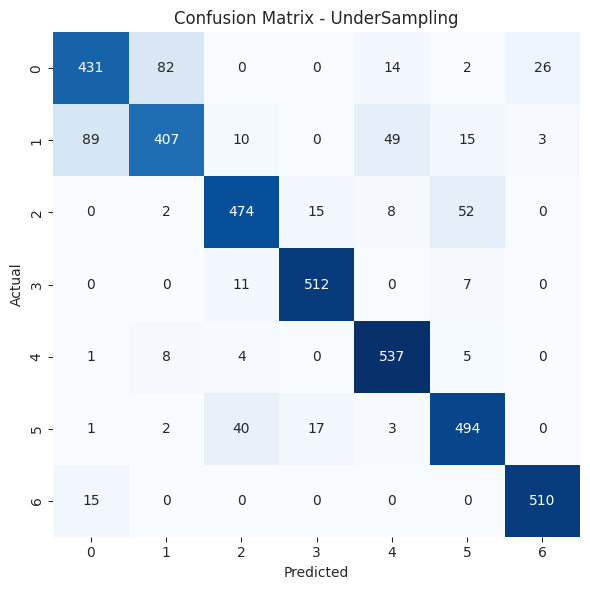


📋 Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.78      0.79       555
           1       0.81      0.71      0.76       573
           2       0.88      0.86      0.87       551
           3       0.94      0.97      0.95       530
           4       0.88      0.97      0.92       555
           5       0.86      0.89      0.87       557
           6       0.95      0.97      0.96       525

    accuracy                           0.87      3846
   macro avg       0.87      0.88      0.87      3846
weighted avg       0.87      0.87      0.87      3846



87.4934997399896

In [46]:
evaluate_model(model_1,"UnderSampling",X_test, y_test)

### 2. Random over-sampling
####   It consists of adding more examples from the minority class (over-sampling).

In [47]:
over_sampled_data = all_features_df.copy()
maximum_class_size = np.max(over_sampled_data['Cover_Type'].value_counts().values)
print("Size of largest class:",maximum_class_size)

Size of largest class: 283301


#### Oversampling the minority class
- We will go through the each class subsets and sample 2747 records.

In [48]:
class_subsets = [over_sampled_data.query("Cover_Type=="+str(i)) for i in range(7)]
for i in range(7):
    class_subsets[i] = class_subsets[i].sample(maximum_class_size, replace=True,random_state=42)
over_sampled_data = pd.concat(class_subsets, axis=0).sample(frac=1.0, random_state=42).reset_index(drop=True)

In [49]:
over_sampled_data['Cover_Type'].value_counts()

,count
Cover_Type,
2,283301
6,283301
0,283301
1,283301
4,283301
5,283301
3,283301


In [50]:
X_train, X_test, y_train, y_test = split_and_scale_data(over_sampled_data)

rf_classifier = RandomForestClassifier()
rf_classifier.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
evaluate_model(rf_classifier,"OverSampling",X_test, y_test)

#### Random Forest Classifier

In [ ]:
imbalanced_data = all_features_df.copy()
X_train, X_test, y_train, y_test = split_and_scale_data(imbalanced_data)

rf_classifier = RandomForestClassifier()
rf_classifier.fit(X_train, y_train)

#### In order to calculate roc_auc_score in multi class classification we need to mention strategies either as OvR and OvO strategies.

In [ ]:
# Make predictions
y_pred_probabilities = rf_classifier.predict_proba(X_test)
rf_roc_auc = roc_auc_score(y_test, y_pred_probabilities,multi_class="ovr") #Calculate Roc
print("roc_score",rf_roc_auc)
rf_accuracy =  evaluate_model(rf_classifier,"Imbalanced_data",X_test, y_test)

#### Extra Trees (Random Forests) Classifier

In [ ]:
xrf_classifier = ExtraTreesClassifier()
xrf_classifier.fit(X_train, y_train)
# Make predictions
y_pred_probabilities = xrf_classifier.predict_proba(X_test)
xrf_roc_auc = roc_auc_score(y_test, y_pred_probabilities,multi_class="ovr") #Calculate Roc
print("roc_score",xrf_roc_auc)
xrf_accuracy = evaluate_model(xrf_classifier,"Imbalanced",X_test, y_test)

#### Light Gradient Boosting Machine (LightGBM) Classifier

In [ ]:
# create model apply fit_evaluate_model
lgbm_classifier = LGBMClassifier()
lgbm_classifier.fit(X_train, y_train)
# Make predictions
y_pred_probabilities = lgbm_classifier.predict_proba(X_test)
lgbm_roc_auc = roc_auc_score(y_test, y_pred_probabilities,multi_class="ovr") #Calculate Roc
print("roc_score",lgbm_roc_auc)
lgbm_accuracy = evaluate_model(lgbm_classifier,"Imbalanced",X_test, y_test)

In [ ]:
# create model apply fit_evaluate_model
cat_classifier = CatBoostClassifier(verbose=False)
cat_classifier.fit(X_train, y_train)
# Make predictions
y_pred_probabilities = cat_classifier.predict_proba(X_test)
cat_roc_auc = roc_auc_score(y_test, y_pred_probabilities,multi_class="ovr") #Calculate Roc
print("roc_score",cat_roc_auc)
cat_accuracy = evaluate_model(cat_classifier,"Imbalanced",X_test, y_test)

In [ ]:
# create model apply fit_evaluate_model
xgb_classifier = XGBClassifier(verbose=False)
xgb_classifier.fit(X_train, y_train)
# Make predictions
y_pred_probabilities = xgb_classifier.predict_proba(X_test)
xgb_roc_auc = roc_auc_score(y_test, y_pred_probabilities,multi_class="ovr") #Calculate Roc
print("roc_score",cat_roc_auc)
xgb_accuracy = evaluate_model(xgb_classifier,"Imbalanced",X_test, y_test)

## Evaluate all base Models

In [ ]:
# create dataframe of accuracy and model and sort values
performance_comparison = pd.DataFrame({"Model": [ "LightGBM", "Random Forests", "Extra Trees","cat_accuracy","xgb_accuracy"],
                                       "Accuracy": [ lgbm_accuracy, rf_accuracy, xrf_accuracy,cat_accuracy,xgb_accuracy]})

performance_comparison = performance_comparison.sort_values(by="Accuracy", ascending=True)

# set the plot
plt.figure(figsize=(10,10))
ax = sns.barplot(x="Accuracy", y="Model", data=performance_comparison, palette="Greens_d")

# set title arrange labels
plt.yticks(size = 14)
plt.xticks(size = 14)
plt.title("Accuracy Score of Different Models", size=14)


## Plot Roc Auc Curve

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve,auc
#binarize the y_values

classes=np.unique(y_test)
y_test_binarized=label_binarize(y_test,classes=np.unique(y_test))

# roc curve for classes
fpr = {}
tpr = {}
thresh ={}
roc_auc = dict()

n_class = 7

for i in range(n_class):
    fpr[i], tpr[i], thresh[i] = roc_curve(y_test_binarized[:,i], y_pred_probabilities[:,i])
    roc_auc[i] = auc(fpr[i], tpr[i])

    # plotting
    plt.plot(fpr[i], tpr[i], linestyle='--',
             label='%s vs Rest (AUC=%0.2f)'%(classes[i],roc_auc[i]))

plt.plot([0,1],[0,1],'b--')
plt.xlim([0,1])
plt.ylim([0,1.05])
plt.title('Multiclass ROC curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive rate')
plt.legend(loc='lower right')
plt.show()

### Best Model is Random Forest Classifier with 96 % Accuracy, hence we can save this model

In [ ]:
import pickle

# Save the trained model as a pickle file.
pickle.dump(rf_classifier, open('rf_classifier.pkl', 'wb'))